# 2. Tutorial 2

**Course:** Power Electronics Devices and Components  
**Lecture linkage:** energy bands, intrinsic carrier concentration, doping, majority/minority carriers, conductivity, Hall coefficient, and Fermi-level shift

## 2.1. Blocking-voltage versus drift-resistance design map

Build the trade-off map of a silicon power-diode drift region. Use a one-sided $p^+ - n^-$ structure.
Following constants are given:
- $\varepsilon_\mathrm{s} = 1.04 ~\mathrm{pF/cm}$
- $q = 1.6 \cdot 10^{-19}~\mathrm{C}$
- $\mu_\mathrm{n} = 1000~\mathrm{{cm}^2/Vs}$

The diagrams shall sweep $N_\mathrm{D}$ in range [$1 \cdot 10^{14} \ldots 5 \cdot 10^{15}~\mathrm{cm^{-3}}$]
and $t_\mathrm{d}$ in range [$20 \ldots 200~\mathrm{\mu m}$]

2.1.1 Import necessary modules (numpy as np and matplotlib.pyplot as plt) and add constant variables for the constant values.

2.1.2 Create a function with input parameter  $N_\mathrm{D}$ and $t_\mathrm{d}$, which calculates the punch-through-limited blocking voltage:
$$V_\mathrm{PT} = \frac{qN_\mathrm{D}t_\mathrm{d}^2}{2\varepsilon_\mathrm{s}}.$$

2.1.3 Create a function with input parameter  $N_\mathrm{D}$ and $t_\mathrm{d}$, which calculates the drift-region specific resistance proxy:
$$R_{\mathrm{drift}} \propto \frac{t_\mathrm{d}}{q\mu_\mathrm{n} N_\mathrm{D}}.$$

2.1.4 Plot $V_\mathrm{PT}$ versus $N_\mathrm{D}$ for 4 $t_\mathrm{d}$-values within the given range.

2.1.5 Plot $R_{\mathrm{drift}}$ versus $N_\mathrm{D}$ for the selected $t_\mathrm{d}$

2.1.6 Create a scatter plot of $V_\mathrm{PT}$ versus $R_{\mathrm{drift}}$


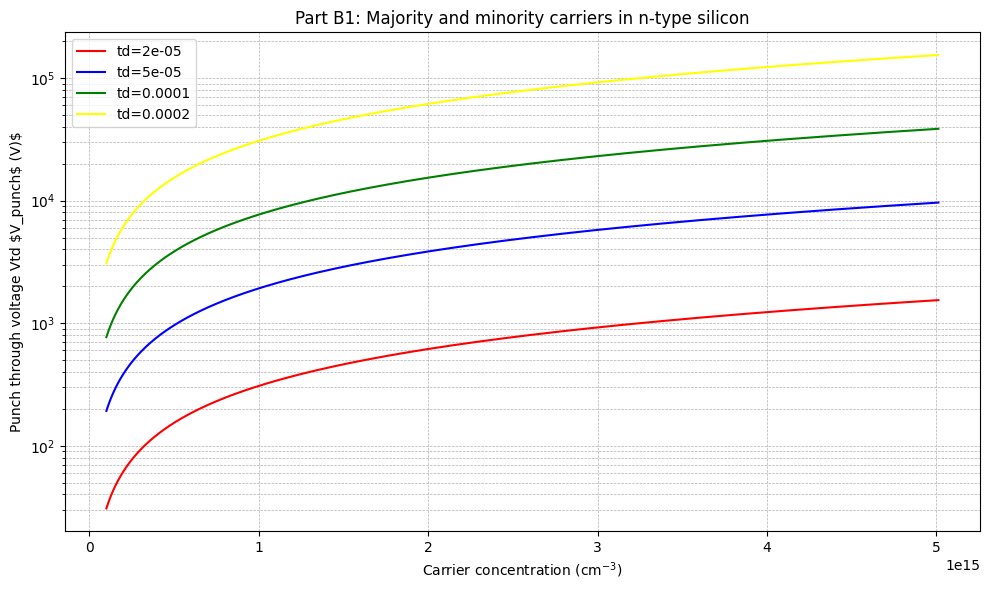

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Fixed constants and material data for the tutorial
# ---------------------------------------------------------------------
eps_s = 104e-12          # 1.04e-12F/cm = 104e-12F/m
q = 1.6e-19              # C
mu_n = 0.1               # 1000 cm^2/Vs = 0.1m^2/Vs

# Subtask 2.1.2: Calculate the bunch through from doping density and and drift length.
def get_v_punch(act_n_D, act_t_d):
    v_punch =  q * act_n_D * (act_t_d ** 2)/ (2 * eps_s)
    return v_punch

# Subtask 2.1.3: Calculate the drift-region specific resistance proxy.
def get_R_drift(act_n_D, act_t_d):
    R_drift =  act_t_d / ( q * mu_n * act_n_D)
    return R_drift

if __name__ == "__main__":
    t_d_parameter = np.array([20e-6, 50e-6, 100e-6, 200e-6])     # explicit task values
    ND_plot = np.logspace(20, 21.7, 300)                         # 1e14/cm^3 ...5e15/cm^3 = 1e20/m^3 ...5e21/m^3

    # Create color list
    v_punch_result_list: np.ndarray = []
    color_list = ['red', 'blue', 'green', 'yellow', 'black', 'white', 'cyan', 'magenta', 'orange', 'purple']


    plt.figure(figsize=(10, 6))
    for i, act_t_d in enumerate(t_d_parameter):
        # Calculate result
        v_punch_t_d = get_v_punch(ND_plot, act_t_d)
        # Create legend per result
        text=f"td={act_t_d}"
        plt.semilogy(ND_plot/1e6, v_punch_t_d, label=text, color=color_list[i])
    # Put legend to upper left
    plt.legend(loc='upper left')
    plt.xlabel(r'Carrier concentration (cm$^{-3}$)')
    plt.ylabel(r'Punch through voltage Vtd $V_punch$ (V)$')
    plt.title('Punch through voltage versus drift length')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show() 

## 2.2 Charge-controlled switching penalty in a power BJT

Visualize why stored charge makes BJT turn-off difficult.
For a simplified model we assume that the total removable stored charge is:
$$Q_{\mathrm{tot}} =  Q_\mathrm{s} + \Delta Q.$$
where $Q_\mathrm{s}$ is charge at edge of saturation and $\Delta Q$ is additional deep-saturation charge.

Use following parameters:
- $Q_\mathrm{s} = 28\mathrm{\mu  C}$
- $V_\mathrm{CC} = 300\mathrm{V}$
- $I_\mathrm{C} = 30\mathrm{A}$
- $\Delta Q = 0~\mathrm{\mu C}, 10~\mathrm{\mu }, 20~\mathrm{\mu C} and 30~\mathrm{\mu C}$
- Reverse base current values: $I_{\mathrm{B,{rev}}} = 2~\mathrm{A}, 4~\mathrm{A} and 6~\mathrm{A}$

2.2.1 Add constant variables for the constant values.

2.2.2 Create a function with input parameter  $\Delta Q$, which calculates total charge $Q_{\mathrm{tot}}$.

2.2.3 Create a function with input parameters  $Q_{\mathrm{tot}}$ and $I_{\mathrm{B, ref}}$, which calculates  storage time  $t_\mathrm{s}$ based on equation
$$t_\mathrm{s} =  \frac{Q_{\mathrm{tot}}}{I_{\mathrm{B},\mathrm{rev}}}.$$

2.2.4 Create a function with input parameter  $t_\mathrm{s}$, which calculates  switch loss energy  $E_{\mathrm{off}}$ (approximation) based on equation
$$E_{\mathrm{off}} =  V_\mathrm{CC} I_\mathrm{C} \cdot t_\mathrm{s}.$$

2.2.5 Comment on the design question: "Is it always beneficial to drive a BJT deeper into saturation?"


## Reflection and discussion questions
1. In Part A, which material had the smallest intrinsic carrier concentration, and how does that connect to its band gap?
2. In Part B, why does the hole concentration decrease as donor doping increases even though the temperature is unchanged?
3. Why does conductivity increase with donor doping, while the magnitude of the Hall coefficient decreases?
4. Why does the Fermi level move upward relative to the intrinsic level as \(N_D\) increases?
5. In Part C, why does silicon move closer to intrinsic behavior at high temperature, while GaN remains strongly extrinsic?

## Suggested extensions for students
1. Repeat Part B for **p-type silicon** by setting \(N_D=0\) and
\[
N_A = [10^{14},\;10^{15},\;10^{16},\;10^{17},\;10^{18}] \;\mathrm{cm^{-3}}
\]
and then adapt the Hall-coefficient sign accordingly.
2. Add **Ge** and **SiC** to Part C and compare all four materials on the same temperature plots.
3. Repeat Part C for a higher donor density, such as \(N_D = 10^{16}\,\mathrm{cm^{-3}}\), and explain how stronger doping delays intrinsic takeover.
4. Replace the single-carrier Hall-coefficient estimate with the full two-carrier Hall expression and compare the results near intrinsic conditions.